### 1. Load the dataset and encode class labels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# The wdbc.data file has no header, so we define column names ourselves
columns = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(1, 31)]

df = pd.read_csv("wdbc.data", header=None, names=columns)
df = df.drop('id', axis=1)   # id column is not useful for prediction
df.head()

,diagnosis,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [2]:
# Encode diagnosis: M (Malignant) = 1, B (Benign) = 0
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])
print("Classes:", le.classes_)   # ['B' 'M'] -> B=0, M=1
df.head()

Classes: ['B' 'M']


,diagnosis,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2. Exploratory Data Analysis

In [3]:
# Class distribution
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

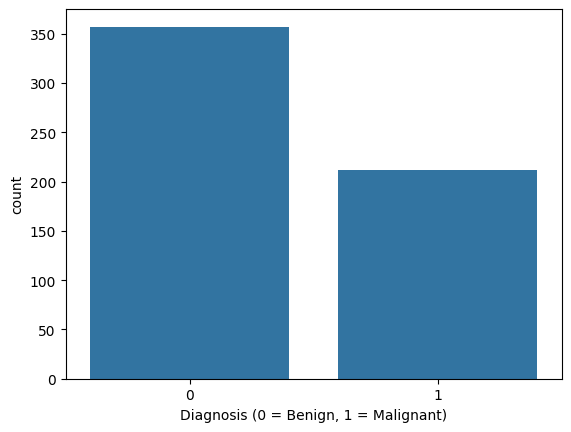

In [4]:
sns.countplot(x='diagnosis', data=df)
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.show()

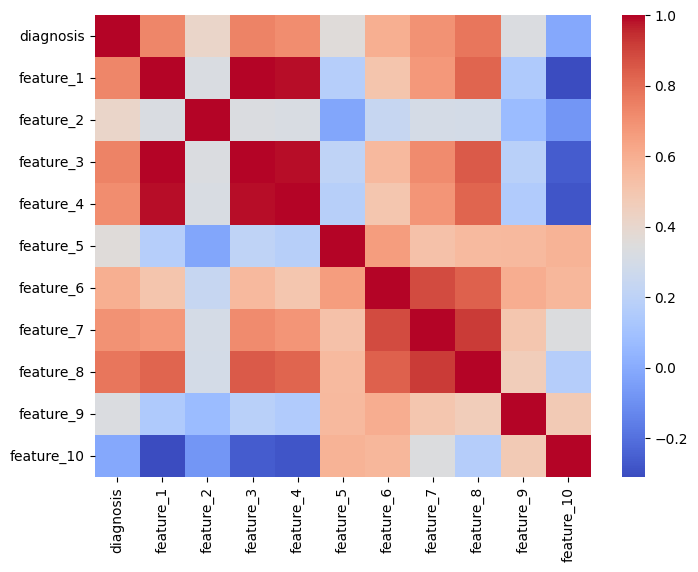

In [5]:
# Correlation heatmap of first 10 features with the target
plt.figure(figsize=(8,6))
sns.heatmap(df.iloc[:, :11].corr(), annot=False, cmap='coolwarm')
plt.show()

### 3. Split the dataset into training and testing sets (80-20)

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (455, 30)
Testing set size: (114, 30)


### 4. Bagging Classifier (base estimator: Decision Tree)

In [7]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Hyperparameter search space for Bagging
bag_param_grid = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.8, 1.0],
    'max_features': [0.5, 1.0]
}

In [8]:
from sklearn.model_selection import GridSearchCV

bag_grid = GridSearchCV(BaggingClassifier(DecisionTreeClassifier(random_state=42), random_state=42),
                         bag_param_grid, cv=5, scoring='accuracy')
bag_grid.fit(X_train, y_train)

print("Best Bagging params:", bag_grid.best_params_)
print("Best CV accuracy: %.4f" % bag_grid.best_score_)

Best Bagging params: {'max_features': 0.5, 'max_samples': 0.8, 'n_estimators': 50}
Best CV accuracy: 0.9604


In [9]:
best_bag = bag_grid.best_estimator_
bag_pred = best_bag.predict(X_test)

### 5. Boosting Classifiers (AdaBoost and Gradient Boosting)

In [10]:
from sklearn.ensemble import AdaBoostClassifier

# Hyperparameter search space for AdaBoost
ada_param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 1]
}

ada_grid = GridSearchCV(AdaBoostClassifier(random_state=42), ada_param_grid, cv=5, scoring='accuracy')
ada_grid.fit(X_train, y_train)

print("Best AdaBoost params:", ada_grid.best_params_)
print("Best CV accuracy: %.4f" % ada_grid.best_score_)

Best AdaBoost params: {'learning_rate': 1, 'n_estimators': 50}
Best CV accuracy: 0.9802


In [11]:
from sklearn.ensemble import GradientBoostingClassifier

# Hyperparameter search space for Gradient Boosting
gb_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [2, 3]
}

gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_param_grid, cv=5, scoring='accuracy')
gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting params:", gb_grid.best_params_)
print("Best CV accuracy: %.4f" % gb_grid.best_score_)

Best Gradient Boosting params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}
Best CV accuracy: 0.9516


In [12]:
# Pick whichever boosting model gave the higher CV accuracy
if ada_grid.best_score_ >= gb_grid.best_score_:
    best_boost = ada_grid.best_estimator_
    print("Selected boosting model: AdaBoost")
else:
    best_boost = gb_grid.best_estimator_
    print("Selected boosting model: Gradient Boosting")

boost_pred = best_boost.predict(X_test)

Selected boosting model: AdaBoost


### 6. Stacked Ensemble (SVM + Naive Bayes + Decision Tree, meta-learner: Logistic Regression)

In [13]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

base_learners = [
    ('svm', SVC(probability=True, random_state=42)),
    ('nb', GaussianNB()),
    ('dt', DecisionTreeClassifier(random_state=42))
]

In [14]:
from sklearn.model_selection import cross_val_score

# Try the stacked model with and without passthrough (original features passed to meta-learner)
for pt in [True, False]:
    stack = StackingClassifier(estimators=base_learners,
                                final_estimator=LogisticRegression(max_iter=5000),
                                passthrough=pt, cv=5)
    scores = cross_val_score(stack, X_train, y_train, cv=5, scoring='accuracy')
    print("passthrough =", pt, "-> CV accuracy: %.4f" % scores.mean())

passthrough = True -> CV accuracy: 0.9495


passthrough = False -> CV accuracy: 0.9473


In [15]:
# passthrough=True gave the better CV accuracy, so we use it for the final model
best_stack = StackingClassifier(estimators=base_learners,
                                 final_estimator=LogisticRegression(max_iter=5000),
                                 passthrough=True, cv=5)
best_stack.fit(X_train, y_train)
stack_pred = best_stack.predict(X_test)

### 7. Evaluation Metrics — Bagging

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test, bag_pred))
print("Precision:", precision_score(y_test, bag_pred))
print("Recall   :", recall_score(y_test, bag_pred))
print("F1 Score :", f1_score(y_test, bag_pred))

Accuracy : 0.9649122807017544
Precision: 0.975609756097561
Recall   : 0.9302325581395349
F1 Score : 0.9523809523809523


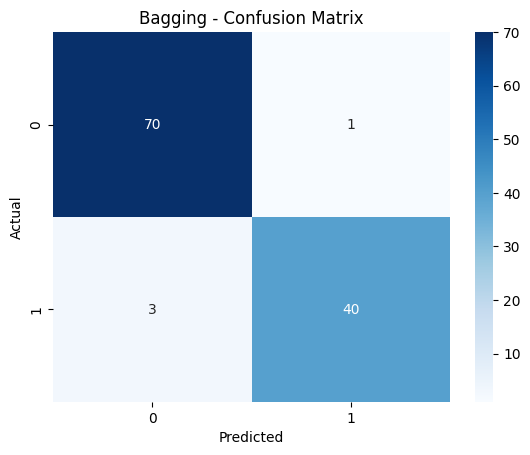

In [17]:
sns.heatmap(confusion_matrix(y_test, bag_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Bagging - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 8. Evaluation Metrics — Boosting

In [18]:
print("Accuracy :", accuracy_score(y_test, boost_pred))
print("Precision:", precision_score(y_test, boost_pred))
print("Recall   :", recall_score(y_test, boost_pred))
print("F1 Score :", f1_score(y_test, boost_pred))

Accuracy : 0.9649122807017544
Precision: 0.975609756097561
Recall   : 0.9302325581395349
F1 Score : 0.9523809523809523


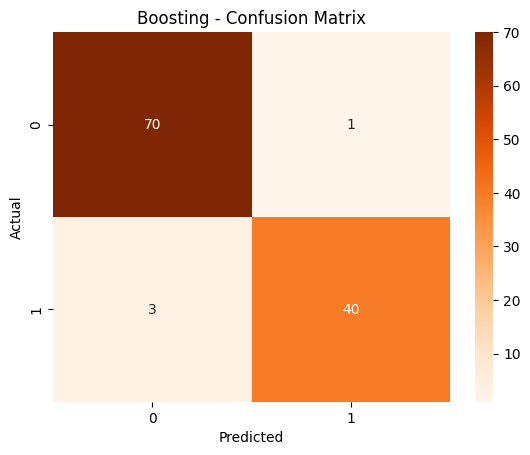

In [19]:
sns.heatmap(confusion_matrix(y_test, boost_pred), annot=True, fmt='d', cmap='Oranges')
plt.title("Boosting - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 9. Evaluation Metrics — Stacked Ensemble

In [20]:
print("Accuracy :", accuracy_score(y_test, stack_pred))
print("Precision:", precision_score(y_test, stack_pred))
print("Recall   :", recall_score(y_test, stack_pred))
print("F1 Score :", f1_score(y_test, stack_pred))

Accuracy : 0.956140350877193
Precision: 0.975
Recall   : 0.9069767441860465
F1 Score : 0.9397590361445783


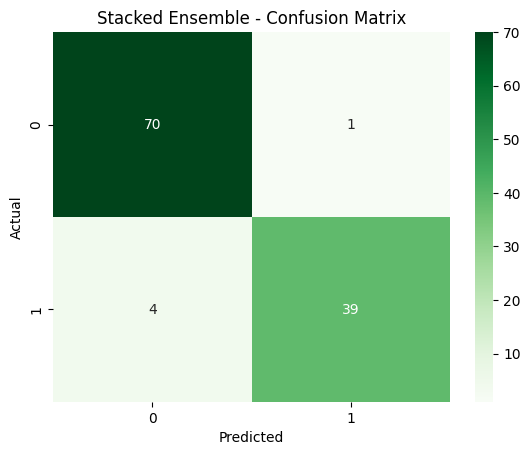

In [21]:
sns.heatmap(confusion_matrix(y_test, stack_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Stacked Ensemble - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 10. ROC Curve and AUC

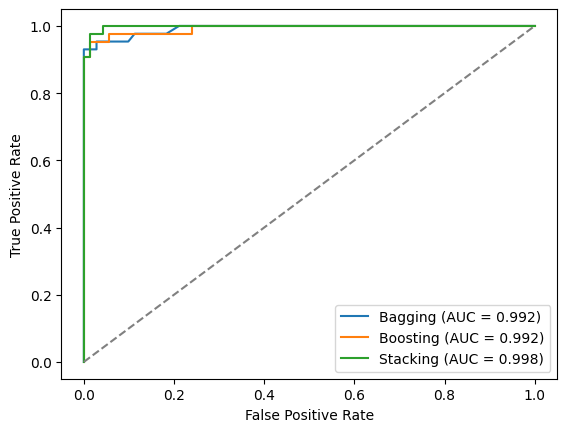

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score

bag_probs = best_bag.predict_proba(X_test)[:, 1]
boost_probs = best_boost.predict_proba(X_test)[:, 1]
stack_probs = best_stack.predict_proba(X_test)[:, 1]

for name, probs in [('Bagging', bag_probs), ('Boosting', boost_probs), ('Stacking', stack_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, probs):.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### 11. Performance Comparison

In [23]:
results = pd.DataFrame({
    'Accuracy': [accuracy_score(y_test, bag_pred), accuracy_score(y_test, boost_pred), accuracy_score(y_test, stack_pred)],
    'Precision': [precision_score(y_test, bag_pred), precision_score(y_test, boost_pred), precision_score(y_test, stack_pred)],
    'Recall': [recall_score(y_test, bag_pred), recall_score(y_test, boost_pred), recall_score(y_test, stack_pred)],
    'F1 Score': [f1_score(y_test, bag_pred), f1_score(y_test, boost_pred), f1_score(y_test, stack_pred)]
}, index=['Bagging', 'Boosting', 'Stacking'])

results

,Accuracy,Precision,Recall,F1 Score
Bagging,0.964912,0.97561,0.930233,0.952381
Boosting,0.964912,0.97561,0.930233,0.952381
Stacking,0.956140,0.97500,0.906977,0.939759
